In [51]:
import json
from collections import Counter
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV
from sentence_transformers import SentenceTransformer
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

/tmp/ipykernel_644676/4224434262.py:5: UserWarning: Overwriting the cmap 'rose' that was already in the registry.
  mpl.colormaps.register(rose, name="rose", force=True)


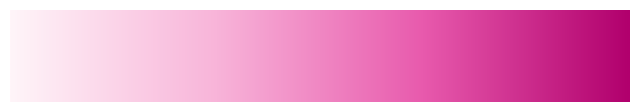

In [23]:
rose = LinearSegmentedColormap.from_list(
    "rose",
    ["#fff5f9", "#f8b4d9", "#e85aad", "#b1006d"]
)
mpl.colormaps.register(rose, name="rose", force=True)

# exemple d'affichage
gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1.2))
plt.imshow(gradient, aspect="auto", cmap=rose)
plt.axis("off")
plt.show()

In [5]:
gt_path = "GT/data_annotee_sujet.json"
with open(gt_path, "r") as f:
    gt_data = json.load(f)

# Investigation sur la tête des données

In [10]:
for item in gt_data[:3]:
    print(item)

{'id': 1, 'annotations': [{'id': 1, 'completed_by': 1, 'result': [{'value': {'choices': ['Réalité', 'Mention marginale']}, 'id': 'ryQc0PKYwc', 'from_name': 'sentiment', 'to_name': 'text', 'type': 'choices', 'origin': 'manual'}], 'was_cancelled': False, 'ground_truth': False, 'created_at': '2026-04-03T09:52:18.492918Z', 'updated_at': '2026-04-03T10:01:52.923272Z', 'draft_created_at': None, 'lead_time': 39.749, 'prediction': {}, 'result_count': 1, 'unique_id': 'd2dc3c64-84d2-420c-88f5-4c1d3f41108e', 'import_id': None, 'last_action': None, 'bulk_created': False, 'task': 1, 'project': 2, 'updated_by': 1, 'parent_prediction': None, 'parent_annotation': None, 'last_created_by': None}], 'drafts': [], 'predictions': [], 'data': {'text': '[PARIS- L\'AVANT-PROJET DE LOI SUR LA SECURITE INTERIEURE...]\nPARIS -\nL\'AVANT-PROJET DE LOI SUR LA SECURITE INTERIEURE\nLe Monde\n"La droite s\'était engagée à faire de la lutte contre l\'insécurité sa priorité. (...) Mais le projet de réforme que prépare\n

In [4]:
labels = []
marginal_fiction = 0
for task in gt_data:
    for annotation in task["annotations"]:
        for result in annotation["result"]:
            if "choices" in result.get("value", {}):
                labels.extend(result["value"]["choices"])
                if "Mention marginale" in result["value"]["choices"] and "Fiction" in result["value"]["choices"]:
                    marginal_fiction += 1

# Comptage
counts = Counter(labels)
classes = list(counts.keys())
values  = list(counts.values())

In [5]:
counts

Counter({'Réalité': 220,
         'Mention marginale': 179,
         'Fiction': 75,
         'Hors-sujet': 16})

In [6]:
marginal_fiction

65

In [7]:
len(gt_data)

312

# Préparation des données pour entraîner le classifieur

In [6]:
label_types = []
label_pertinence = []
textes = []
for task in gt_data:
    for annotation in task["annotations"]:
        for result in annotation["result"]:
            if "choices" in result.get("value", {}):
                if task["data"]["text"] != "":
                    if "Mention marginale" in result["value"]["choices"]:
                        label_pertinence.append("Mention marginale")
                    elif "Hors-sujet" in result["value"]["choices"]:
                        label_pertinence.append("Hors-sujet")
                    else:
                        label_pertinence.append("Pertinent")
                    if "Fiction" in result["value"]["choices"]:
                        label_types.append("Fiction") 
                    elif "Réalité" in result["value"]["choices"]:
                        label_types.append("Réalité")
                    else:
                        label_types.append("Inconnu")
                        print(task)
                    textes.append(task["data"]["text"])

In [4]:
assert len(label_types) == len(label_pertinence) == len(textes)

## Création des embeddings

In [46]:

# Encodage une seule fois (coûteux, inutile de le répéter)
model = SentenceTransformer("Lajavaness/sentence-camembert-large")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 710.77it/s]


In [47]:
def encode_long_text(model, text, max_chars=1500, overlap=200):
    """Découpe un texte long en chunks et moyenne les embeddings."""
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start:start + max_chars])
        start += max_chars - overlap
    embeddings = model.encode(chunks)
    return np.mean(embeddings, axis=0)

In [49]:
model.max_seq_length = 512
X = np.array([encode_long_text(model, t) for t in textes])

KeyboardInterrupt: 

In [7]:
X = np.load("GT/embeddings_gt.npy").astype(np.float32)

# Entraînement des modèles

## Genre de l'article

### Avec TF-IDF

In [8]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=10_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ("clf", LinearSVC(
        C=0.1,
        class_weight="balanced",
        max_iter=2000,
    )),
])

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [10_000, 20_000, 50_000],
    "clf__C": [0.1, 1.0, 5.0, 10.0],
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(textes, label_types)


print("Meilleurs params :", grid.best_params_)
print("Meilleur F1-macro :", grid.best_score_)

Meilleurs params : {'clf__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
Meilleur F1-macro : 0.8910800323737954


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)
y_pred = cross_val_predict(pipeline, textes, label_types, cv=cv)
print(classification_report(label_types, y_pred))

              precision    recall  f1-score   support

     Fiction       0.84      0.83      0.83        76
     Réalité       0.94      0.95      0.95       230

    accuracy                           0.92       306
   macro avg       0.89      0.89      0.89       306
weighted avg       0.92      0.92      0.92       306



### Avec des embeddings

In [ ]:
# GridSearch uniquement sur le classifieur
clf = LinearSVC(class_weight="balanced", max_iter=2000)

param_grid = {
    "C": [0.01, 0.1, 1.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)

grid = GridSearchCV(
    clf,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X, label_types)

print("Meilleur C :", grid.best_params_)
print("Meilleur F1-macro :", grid.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Meilleur C : {'C': 0.1}
Meilleur F1-macro : 0.8871532953060548


In [ ]:
clf = LinearSVC(C=0.1, class_weight="balanced", max_iter=2000)
y_pred = cross_val_predict(clf, X, label_types, cv=cv)
print(classification_report(label_types, y_pred))

              precision    recall  f1-score   support

     Fiction       0.82      0.84      0.83        76
     Réalité       0.95      0.94      0.94       230

    accuracy                           0.92       306
   macro avg       0.88      0.89      0.89       306
weighted avg       0.92      0.92      0.92       306



### Avec la combinaison des deux
(On garde les meilleurs paramètres du TF_IDF définis précédemment)

In [30]:
class TextExtractor(BaseEstimator, TransformerMixin):
    """Extrait le texte (index 0) d'une liste de tuples (texte, embedding)"""
    def fit(self, X, y=None): return self
    def transform(self, X): return [x[0] for x in X]

class EmbeddingExtractor(BaseEstimator, TransformerMixin):
    """Extrait l'embedding (index 1) d'une liste de tuples (texte, embedding)"""
    def fit(self, X, y=None): return self
    def transform(self, X): return np.vstack([x[1] for x in X])

# Branches combinées avec FeatureUnion
features = FeatureUnion([
    ("tfidf", Pipeline([
        ("text", TextExtractor()),
        ("vec",  TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ])),
    ("embed", EmbeddingExtractor()),
])

pipeline = Pipeline([
    ("features", features),
    ("clf", LinearSVC(class_weight="balanced", max_iter=2000)),
])

param_grid = {
    "features__tfidf__vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "features__tfidf__vec__max_features": [10_000, 20_000, 50_000],
    "features__tfidf__vec__min_df": [1, 2],
    "clf__C": [0.1, 1.0, 5.0, 10.0],
}

In [31]:
# Input = liste de tuples (texte, embedding)
X_input = list(zip(textes, X))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)
grid_type = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_type.fit(X_input, label_types)

print("Meilleurs params :", grid_type.best_params_)
print("Meilleur F1-macro :", f"{grid_type.best_score_:.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Meilleurs params : {'clf__C': 0.1, 'features__tfidf__vec__max_features': 10000, 'features__tfidf__vec__min_df': 1, 'features__tfidf__vec__ngram_range': (1, 1)}
Meilleur F1-macro : 0.905


In [32]:
y_pred = cross_val_predict(grid_type.best_estimator_, X_input, label_types, cv=cv)

print(classification_report(label_types, y_pred))

              precision    recall  f1-score   support

     Fiction       0.84      0.88      0.86        76
     Réalité       0.96      0.94      0.95       230

    accuracy                           0.93       306
   macro avg       0.90      0.91      0.91       306
weighted avg       0.93      0.93      0.93       306



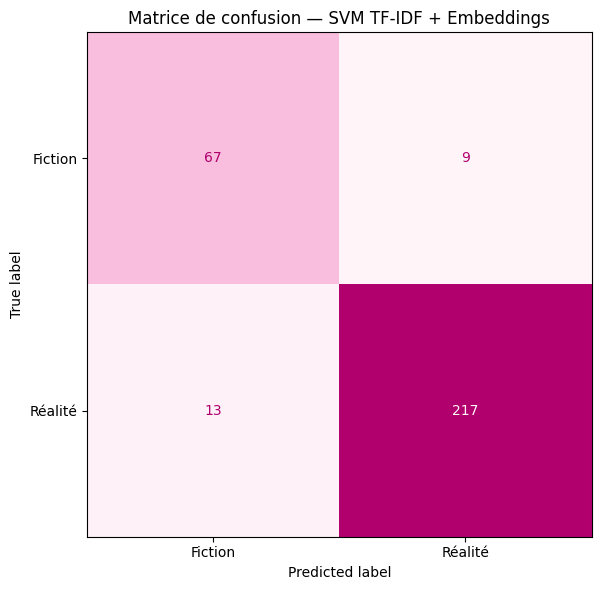

In [33]:
cm = confusion_matrix(label_types, y_pred, labels=grid_type.classes_ if hasattr(grid_type, "classes_") else sorted(set(label_types)))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(set(label_types))
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="rose", colorbar=False)
ax.set_title("Matrice de confusion — SVM TF-IDF + Embeddings")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

*Conclusion* : L'utilisation des embeddings seuls accordent une légère performance supplémentaire overall, vu les ressources que ça demande on pourrait croire que ce n'est pas utile de le faire, cependant lorsqu'on s'intéresse au score de + prêt on voit que le f1 score et surtout le rappel pour les articles à propos de faits réels sont + haut. Comme je m'intéresse surtout à l'actualité c'est donc plus pertinent de garder les embeddings et vu que combiner avec le Tf-IDF ne coûte rien de plus en termes de performance, et que ça fait des scores un peu plus haut, autant garder les deux

## Pertinence de l'article

### Avec TF-IDF

In [ ]:
param_grid_per = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [10_000, 20_000, 50_000],
    "clf__C": [0.1, 1.0, 5.0, 10.0],
}

grid_per = GridSearchCV(pipeline, param_grid_per, cv=cv, scoring="f1_macro", n_jobs=-1)
grid_per.fit(textes, label_pertinence)


print("Meilleurs params :", grid_per.best_params_)
print("Meilleur F1-macro :", grid_per.best_score_)

Meilleurs params : {'clf__C': 5.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Meilleur F1-macro : 0.507085286062319


In [39]:
pipeline_per = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ("clf", LinearSVC(
        C=5.0,
        class_weight="balanced",
        max_iter=2000,
    )),
])

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)
y_pred = cross_val_predict(pipeline_per, textes, label_pertinence, cv=cv)
print(classification_report(label_pertinence, y_pred))

                   precision    recall  f1-score   support

       Hors-sujet       0.00      0.00      0.00        10
Mention marginale       0.76      0.91      0.83       179
        Pertinent       0.82      0.66      0.73       117

         accuracy                           0.78       306
        macro avg       0.53      0.52      0.52       306
     weighted avg       0.76      0.78      0.76       306



/home/plume/miniconda3/envs/svm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/plume/miniconda3/envs/svm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/plume/miniconda3/envs/svm/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

### Avec les embeddings

In [47]:
pipeline_embed = Pipeline([
    ("clf", LinearSVC(class_weight="balanced", max_iter=2000)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 5.0, 10.0],  # ← préfixe clf__ obligatoire dans une Pipeline
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_embed = GridSearchCV(
    pipeline_embed,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid_embed.fit(X, label_pertinence)  # X = embeddings numpy (float32)

print("Meilleur C :", grid_embed.best_params_)
print("Meilleur F1-macro :", f"{grid_embed.best_score_:.3f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Meilleur C : {'clf__C': 0.01}
Meilleur F1-macro : 0.545


In [48]:
y_pred = cross_val_predict(grid_embed.best_estimator_, X, label_pertinence, cv=cv)
print(classification_report(label_pertinence, y_pred))

                   precision    recall  f1-score   support

       Hors-sujet       0.00      0.00      0.00        10
Mention marginale       0.82      0.89      0.85       179
        Pertinent       0.81      0.75      0.78       117

         accuracy                           0.81       306
        macro avg       0.54      0.55      0.55       306
     weighted avg       0.79      0.81      0.80       306



### Avec la combinaison des deux

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=26112002)
grid_per = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_per.fit(X_input, label_pertinence)

print("Meilleurs params :", grid_per.best_params_)
print("Meilleur F1-macro :", f"{grid_per.best_score_:.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Meilleurs params : {'clf__C': 0.1, 'features__tfidf__vec__max_features': 10000, 'features__tfidf__vec__min_df': 1, 'features__tfidf__vec__ngram_range': (1, 3)}
Meilleur F1-macro : 0.513


In [35]:
y_pred = cross_val_predict(grid_per.best_estimator_, X_input, label_pertinence, cv=cv)

print(classification_report(label_pertinence, y_pred))

                   precision    recall  f1-score   support

       Hors-sujet       0.00      0.00      0.00        10
Mention marginale       0.80      0.83      0.81       179
        Pertinent       0.73      0.73      0.73       117

         accuracy                           0.76       306
        macro avg       0.51      0.52      0.51       306
     weighted avg       0.75      0.76      0.76       306



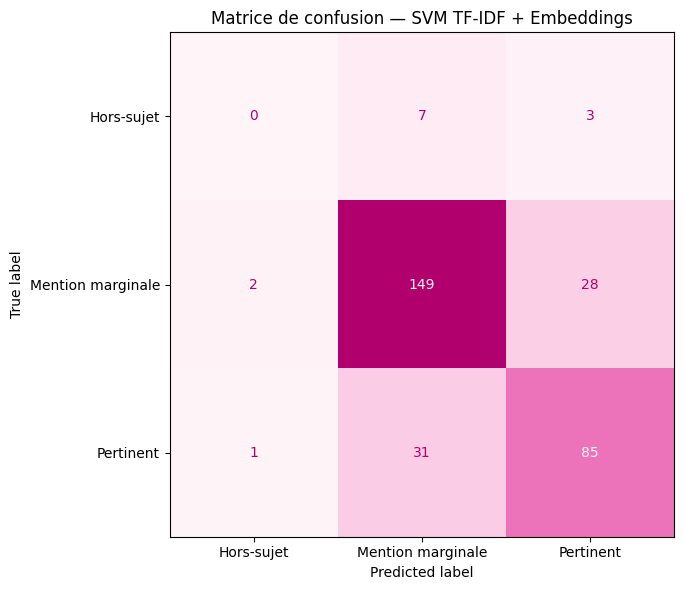

In [36]:
cm = confusion_matrix(label_pertinence, y_pred, labels=grid_per.classes_ if hasattr(grid_per, "classes_") else sorted(set(label_pertinence)))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(set(label_pertinence))
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="rose", colorbar=False)
ax.set_title("Matrice de confusion — SVM TF-IDF + Embeddings")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## On run les modèles

In [54]:
def add_metainfo(json_path, model_type, model_per):
    with open(json_path, "r") as f:
        data = json.load(f)

    if data['texte'] == "":
        print(f"Texte vide dans {json_path}, aucune métainfo ajoutée.")
        return
    
    if not data.get("embedding"):
        print(f"Pas d'embeddings trouvés dans {json_path}, aucune métainfo ajoutée.")
        return
    else:
        embeddings = np.array(data["embedding"], dtype=np.float32)

    X= [(data['texte'], embeddings)]
    

    if not data.get('type'):
        data['type'] = model_type.predict(X).tolist()[0]

    if not data.get('pertinence'):
        data['pertinence'] = model_per.predict(X).tolist()

    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

In [55]:
source_folder = "json_output_embed"

for root, dirs, files in os.walk(source_folder):
    json_files = [f for f in files if f.endswith(".json")]
    
    if not json_files:
        continue

    for filename in json_files:
        src_path = os.path.join(root, filename)
        add_metainfo(src_path, grid_type.best_estimator_, grid_per.best_estimator_)

Texte vide dans json_output_embed/2000/05/baptis-ex-girlfriends-sur-lequ_sans-date_0129.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2000/01/nouvelles-sur-les-c-l-brit-s-s_sans-date_0108.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/06/but-he-announced-thursday-he-w_sans-date_0234.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/10/prostitution-is-legal-in-turke_sans-date_0366.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/03/orchestr-s-par-la-pr-fecture-d_sans-date_0049.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/05/communications-regulator-or-co_sans-date_0460.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/11/best-57-was-stung-on-wednesday_sans-date_0247.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/07/cameraman-surmala-noche-john-c_sans-date_0144.json, aucune métainfo ajoutée.
Texte vide dans json_output_embed/2003/07/archer